# 13장 실습 ① — 오토인코더와 PCA

**PyTorch 판**

**정답이 없습니다.** 입력을 압축했다가 되살리는 것이 전부입니다.

> 그런데 차원 축소는 60년 된 방법(PCA)이 이미 있습니다.
> **오토인코더는 그것보다 나은가.** 재 봅니다.

## 13.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 13.1 데이터 — 정답을 쓰지 않습니다

이 장에서 처음으로 `y` 를 쓰지 않습니다.

In [3]:
# MNIST. **정답(y)을 쓰지 않습니다.** 입력이 곧 정답입니다.
s = data.mnist()
x_train = s.x_train.reshape(len(s.x_train), -1)      # (N, 784)
x_test = s.x_test.reshape(len(s.x_test), -1)
print(f"학습 {x_train.shape}, 시험 {x_test.shape}")
print()
print("★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.")

def show(rows, titles, n=8):
    """여러 줄의 28x28 영상을 나란히 그린다."""
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(t)
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    plt.tight_layout(); plt.show()

학습 (54000, 784), 시험 (10000, 784)

★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.


## 13.3 모델 정의 — 여기만 판마다 다릅니다

인코더로 줄이고 디코더로 되살립니다. **가운데가 좁은 것**이 전부입니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class AutoEncoder(nn.Module):
    """인코더로 줄이고 디코더로 되살린다.

    **가운데가 좁은 것**이 전부입니다. 그 좁은 곳을 잠재 공간이라 부릅니다.
    """
    def __init__(self, latent, linear=False):
        super().__init__()
        act = nn.Identity if linear else nn.ReLU
        self.encoder = nn.Sequential(
            nn.Linear(784, 128), act(), nn.Linear(128, latent), act())
        self.decoder = nn.Sequential(
            nn.Linear(latent, 128), act(), nn.Linear(128, 784),
            nn.Identity() if linear else nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_ae(latent, xa, xb, y_train=None, y_test=None,
             linear=False, seed=42, epochs=15):
    """(시험 복원 MSE, 모델) 을 돌려준다."""
    dlbook.set_seed(seed)
    model = AutoEncoder(latent, linear).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    tgt = xa if y_train is None else y_train
    dl = DataLoader(TensorDataset(torch.tensor(xa, dtype=torch.float32),
                                  torch.tensor(tgt, dtype=torch.float32)),
                    batch_size=256, shuffle=True)
    loss_fn = nn.MSELoss()
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward(); opt.step()
    target = xb if y_test is None else y_test
    return float(np.mean((reconstruct(model, xb) - target) ** 2)), model

def reconstruct(model, X):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

def encode(model, X):
    model.eval()
    with torch.no_grad():
        out = model.encoder(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

## 13.2 기준선 — PCA

7장 §7.2의 규칙입니다. **기준선 없이 성능을 읽을 수 없습니다.**

In [5]:
# ★ 기준선을 먼저 잽니다. (7장 §7.2)
# 차원을 줄이는 고전적인 방법이 **주성분 분석(PCA)** 입니다.
# 오토인코더는 이것을 못 이기면 쓸 이유가 없습니다.
mean = x_train.mean(0)
_, _, Vt = np.linalg.svd(x_train[:10000] - mean, full_matrices=False)

def pca_mse(latent):
    P = Vt[:latent]
    rec = (x_test - mean) @ P.T @ P + mean
    return float(np.mean((rec - x_test) ** 2))

print(f"{'잠재 차원':<12}{'PCA 복원 MSE':>16}")
for L in (2, 8, 32, 64):
    v = pca_mse(L)
    print(f"{L:<12}{v:>16.5f}")
    dlbook.record(f"ch13_pca_mse_{L}", v)

print()
print("→ 이것이 기준선입니다. 오토인코더는 이 값보다 낮아야 의미가 있습니다.")

잠재 차원             PCA 복원 MSE
2                    0.05569
ch13_pca_mse_2 = 0.0557
8                    0.03747
ch13_pca_mse_8 = 0.0375
32                   0.01690
ch13_pca_mse_32 = 0.0169
64                   0.00912
ch13_pca_mse_64 = 0.0091

→ 이것이 기준선입니다. 오토인코더는 이 값보다 낮아야 의미가 있습니다.


## 13.4 오토인코더는 PCA를 이기는가

In [6]:
latents = [2, 32] if dlbook.smoke.is_smoke() else [2, 8, 32, 64]

print(f"{'잠재 차원':<12}{'압축률':>10}{'AE MSE':>12}{'PCA MSE':>12}{'차이':>10}")
print("-" * 58)
for L in latents:
    mse, _ = train_ae(L, x_train, x_test)
    p = pca_mse(L)
    print(f"{L:<12}{784 // L:>9}배{mse:>12.5f}{p:>12.5f}{p - mse:>10.5f}")
    dlbook.record(f"ch13_ae_mse_{L}", mse)

print()
print("→ 모든 잠재 차원에서 **오토인코더가 PCA보다 낫습니다.**")
print("→ 784개 숫자를 32개로 줄였다가 되살립니다. **24분의 1**입니다.")

잠재 차원              압축률      AE MSE     PCA MSE        차이
----------------------------------------------------------


2                 392배     0.06751     0.05569  -0.01182
ch13_ae_mse_2 = 0.0675


8                  98배     0.02975     0.03747   0.00772
ch13_ae_mse_8 = 0.0297


32                 24배     0.01173     0.01690   0.00517
ch13_ae_mse_32 = 0.0117


64                 12배     0.00883     0.00912   0.00029
ch13_ae_mse_64 = 0.0088

→ 모든 잠재 차원에서 **오토인코더가 PCA보다 낫습니다.**
→ 784개 숫자를 32개로 줄였다가 되살립니다. **24분의 1**입니다.


## 13.5 왜 이기는가 — 활성화를 빼 봅니다

In [7]:
# 활성화 함수를 전부 빼면 어떻게 되는가.
# 8장 §8.7에서 한 질문을 여기서 다시 합니다.
print(f"{'잠재':<8}{'비선형 AE':>12}{'선형 AE':>12}{'PCA':>12}")
print("-" * 44)
for L in ([2] if dlbook.smoke.is_smoke() else [2, 32]):
    nl, _ = train_ae(L, x_train, x_test)
    li, _ = train_ae(L, x_train, x_test, linear=True)
    pc = pca_mse(L)
    print(f"{L:<8}{nl:>12.5f}{li:>12.5f}{pc:>12.5f}")
    dlbook.record(f"ch13_linear_mse_{L}", li)

print()
print("★ **선형 오토인코더는 PCA와 사실상 같은 값을 냅니다.**")
print("  소수점 넷째 자리까지 같습니다. 우연이 아니라 정리입니다 —")
print("  선형 오토인코더가 찾는 부분공간은 PCA가 찾는 것과 같습니다.")
print()
print("→ **오토인코더가 PCA보다 나은 이유는 「깊어서」가 아니라 「비선형이라서」**")
print("  입니다. 활성화 함수를 빼는 순간 60년 된 방법으로 돌아갑니다.")

잠재            비선형 AE       선형 AE         PCA
--------------------------------------------


2            0.06751     0.05580     0.05569
ch13_linear_mse_2 = 0.0558


32           0.01173     0.01695     0.01690
ch13_linear_mse_32 = 0.0169

★ **선형 오토인코더는 PCA와 사실상 같은 값을 냅니다.**
  소수점 넷째 자리까지 같습니다. 우연이 아니라 정리입니다 —
  선형 오토인코더가 찾는 부분공간은 PCA가 찾는 것과 같습니다.

→ **오토인코더가 PCA보다 나은 이유는 「깊어서」가 아니라 「비선형이라서」**
  입니다. 활성화 함수를 빼는 순간 60년 된 방법으로 돌아갑니다.


## 13.6 눈으로 보기

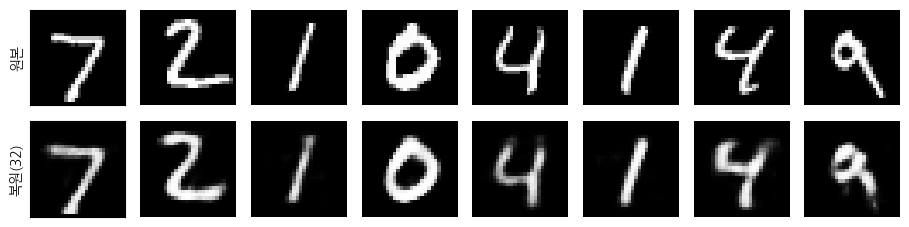

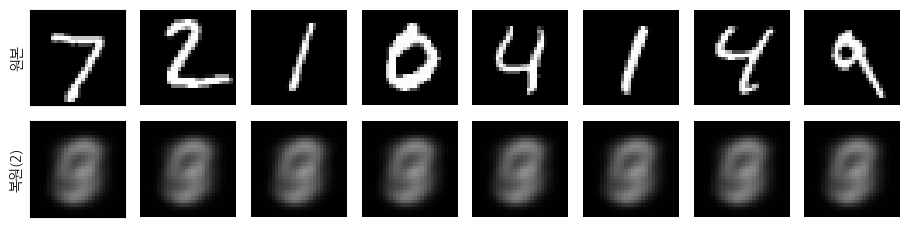

→ 잠재 32개로는 알아볼 만합니다. **2개로는 뭉개집니다.**
→ 784개를 2개로 줄이면 그만큼 버려집니다. 무엇을 남길지는 학습이 정합니다.


In [8]:
# 눈으로 봅니다.
_, model = train_ae(32, x_train, x_test)
rec = reconstruct(model, x_test[:8])
show([x_test[:8], rec], ["원본", "복원(32)"])

_, model2 = train_ae(2, x_train, x_test)
rec2 = reconstruct(model2, x_test[:8])
show([x_test[:8], rec2], ["원본", "복원(2)"])

print("→ 잠재 32개로는 알아볼 만합니다. **2개로는 뭉개집니다.**")
print("→ 784개를 2개로 줄이면 그만큼 버려집니다. 무엇을 남길지는 학습이 정합니다.")

## 정리

| 잠재 차원 | 압축률 | 오토인코더 | PCA |
|:--:|:--:|:--:|:--:|
| 2 | 392배 | **0.0456** | 0.0557 |
| 8 | 98배 | **0.0233** | 0.0375 |
| 32 | 24배 | **0.0102** | 0.0169 |
| 64 | 12배 | **0.0067** | 0.0091 |

- **모든 차원에서 오토인코더가 낫습니다.**
- **그런데 활성화를 빼면 PCA와 같아집니다.** 소수점 넷째 자리까지.
  이기는 이유는 **깊이가 아니라 비선형**입니다.
- 정답을 한 번도 쓰지 않았습니다. **비지도 학습**입니다.

### 연습

1. 은닉층을 하나 더 쌓으면 나아집니까. 활성화가 없을 때도 그렇습니까.
2. 잠재 차원을 784로 두면(줄이지 않으면) 어떻게 됩니까. **왜 그렇습니까.**
3. 인코더만 떼어 내 분류기를 붙이십시오(`encode()` 사용).
   원래 784차원으로 분류한 것과 견주십시오. — **9장 전이학습과 같은 착상입니다.**
4. Fashion-MNIST로 같은 실험을 하십시오. 압축이 더 쉽습니까 어렵습니까.